# 📈 Actividad 10 — Reexploración Post-ETL (Multimodal + NASA)
**CRÍTICO** — Evidencia visual del dataset maestro multimodal para la tesis.

Gráficos:
1. Análisis Multivariable: Producción, Precio y Clima
2. Heatmap de Correlación: Producción × Emergencias × Clima × Estacionalidad
3. Boxplot: Anomalías de Producción Anual

In [1]:
%matplotlib inline
import os, sys, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; PROCESSED=DIRS['processed']
REPORTS=DIRS['reports']; PG_URI=CFG['PG_URI']
print(f"✅ Setup OK | {os.getcwd()}")

✅ Setup OK | D:\CICLO 9\Machine-Learning-Multimodal--Agro-NLP-Clima-


In [2]:

import joblib
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(f"{PROCESSED}/master_dataset_fase1_v2.csv")
scaler_path = f"{DIRS['scalers']}/scaler_fase1_v2.pkl"
cols_sc = [c for c in [
    'produccion_t','cosecha_ha','precio_chacra_kg',
    'num_emergencias','total_afectados','has_cultivo_perdidas','n_noticias',
    'temp_max_c', 'temp_min_c', 'precipitacion_mm', 'humedad_rel_pct', 'velocidad_viento', 'radiacion_solar'
] if c in df.columns]

if os.path.exists(scaler_path):
    sc = joblib.load(scaler_path)
    df_real = df.copy()
    if len(cols_sc) == len(sc.scale_):
        df_real[cols_sc] = sc.inverse_transform(df[cols_sc].fillna(0))
        print("✅ Scaler cargado — valores desnormalizados para gráficos")
    else:
        print("⚠️ Las columnas no coinciden con el scaler. Usando valores escalados.")
else:
    df_real = df.copy()
print(f"Dataset: {df.shape} | Rango: {df['fecha_evento'].min()} → {df['fecha_evento'].max()}")


✅ Scaler cargado — valores desnormalizados para gráficos
Dataset: (5880, 21) | Rango: 2021-01 → 2025-08


## 10.1 Gráfico Multivariable: Producción, Precio y Precipitación

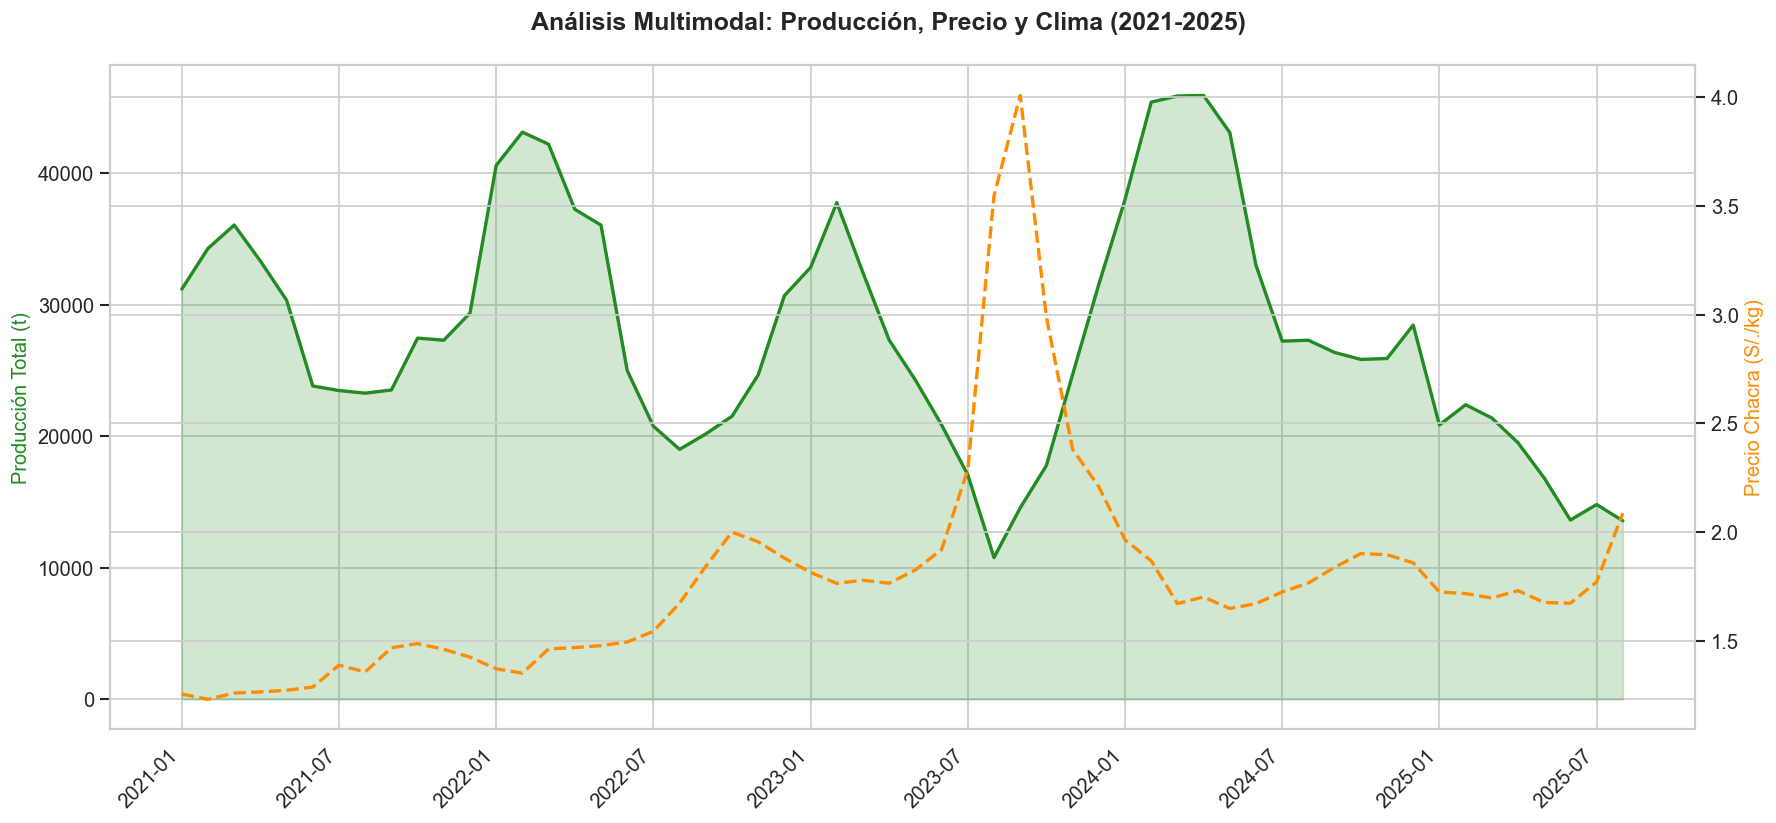

[OK] g13_produccion_vs_precio_vs_clima.png


In [3]:

trend = df_real.groupby('fecha_evento').agg(
    prod=('produccion_t','sum'), 
    precio=('precio_chacra_kg','mean'),
    precip=('precipitacion_mm','mean') if 'precipitacion_mm' in df_real.columns else ('produccion_t','mean')
).reset_index().sort_values('fecha_evento')

fig, ax1 = plt.subplots(figsize=(15, 7))
x = range(len(trend))

# Área: Producción
ax1.fill_between(x, trend['prod'], alpha=0.2, color='forestgreen')
ax1.plot(x, trend['prod'], color='forestgreen', linewidth=2, label='Producción (t)')
ax1.set_ylabel('Producción Total (t)', color='forestgreen', fontsize=12)
ax1.set_xticks(range(0, len(trend), 6))
ax1.set_xticklabels(trend['fecha_evento'].iloc[::6], rotation=45, ha='right')

# Eje 2: Precio
ax2 = ax1.twinx()
ax2.plot(x, trend['precio'], color='darkorange', linewidth=2, linestyle='--', label='Precio (S/./kg)')
ax2.set_ylabel('Precio Chacra (S/./kg)', color='darkorange', fontsize=12)

# Eje 3: Precipitación
if 'precipitacion_mm' in df_real.columns:
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.12))
    ax3.plot(x, trend['precip'], color='royalblue', linewidth=1.5, linestyle=':', label='Precip. (mm)')
    ax3.set_ylabel('Precipitación (mm/día)', color='royalblue', fontsize=12)

fig.suptitle('Análisis Multimodal: Producción, Precio y Clima (2021-2025)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g13_produccion_vs_precio_vs_clima.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] g13_produccion_vs_precio_vs_clima.png")


## 10.2 Heatmap de Correlación Extendido

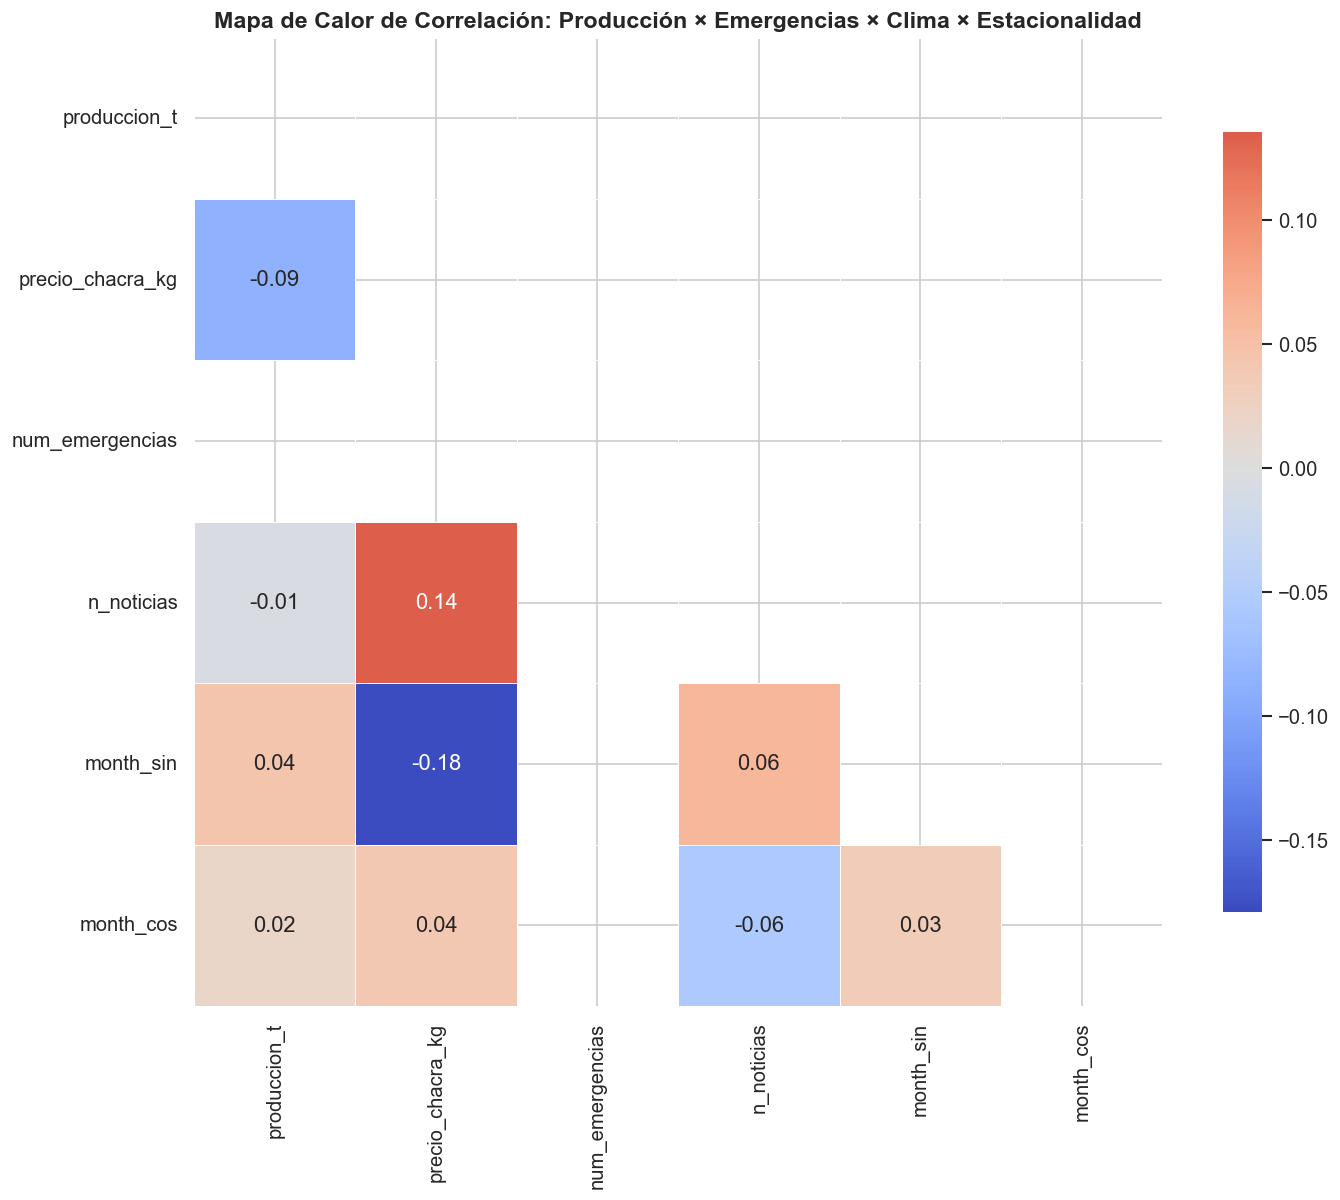

[OK] g14_correlacion_heatmap_final.png


In [4]:

corr_cols = [c for c in [
    'produccion_t','precio_chacra_kg','num_emergencias',
    'n_noticias','temp_max_c','precipitacion_mm','humedad_rel_pct',
    'month_sin','month_cos'
] if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title('Mapa de Calor de Correlación: Producción × Emergencias × Clima × Estacionalidad',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g14_correlacion_heatmap_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] g14_correlacion_heatmap_final.png")


## 10.3 Boxplot: Distribución de Producción por Año

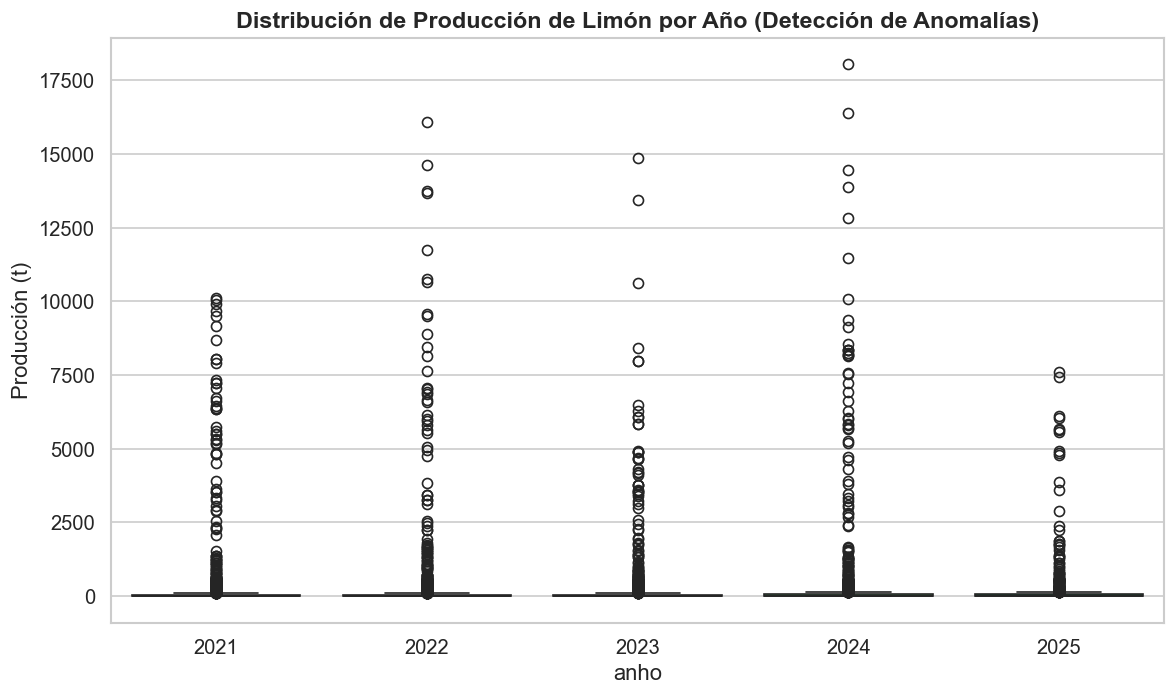

[OK] g15_boxplot_anual.png


In [5]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_real, x='anho', y='produccion_t', palette='YlGn', ax=ax)
ax.set_title('Distribución de Producción de Limón por Año (Detección de Anomalías)', fontsize=14, fontweight='bold')
ax.set_ylabel('Producción (t)')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g15_boxplot_anual.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] g15_boxplot_anual.png")


## 10.4 Resumen Final del Pipeline Multimodal

In [6]:

print("=" * 65)
print("  RESUMEN FINAL — PIPELINE FASE 1 EJECUTADO EXITOSAMENTE")
print("=" * 65)
print(f"\n  Dataset maestro: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Rango temporal: {df['fecha_evento'].min()} → {df['fecha_evento'].max()}")
print()
print("  Columnas del dataset final:")
for c in df.columns:
    print(f"    {c}")
print("\n✅ [ACTIVIDAD 10] COMPLETADA — FASE 1 FINALIZADA")


  RESUMEN FINAL — PIPELINE FASE 1 EJECUTADO EXITOSAMENTE

  Dataset maestro: 5,880 filas × 21 columnas
  Rango temporal: 2021-01 → 2025-08

  Columnas del dataset final:
    fecha_evento
    departamento
    provincia
    produccion_t
    cosecha_ha
    precio_chacra_kg
    num_emergencias
    total_afectados
    has_cultivo_perdidas
    n_noticias
    T2M
    T2M_MAX
    T2M_MIN
    PRECTOTCORR
    RH2M
    ALLSKY_SFC_SW_DWN
    anho
    mes
    trimestre
    month_sin
    month_cos

✅ [ACTIVIDAD 10] COMPLETADA — FASE 1 FINALIZADA
